# Hola &#x1F600;,

Soy **Hesus Garcia** – **"Soy el único Hesus que conoces (y probablemente conocerás) 🌟"** – Sí, como "Jesús", pero con una H que me hace único. Puede sonar raro, pero créeme, ¡no lo olvidarás! Como tu revisor en Triple-Ten, estoy aquí para guiarte y ayudarte a mejorar tu código. Si algo necesita un ajuste, no hay de qué preocuparse; ¡aquí estoy para hacer que tu trabajo brille con todo su potencial! ✨

Cada vez que encuentre un detalle importante en tu código, te lo señalaré para que puedas corregirlo y así te prepares para un ambiente de trabajo real, donde el líder de tu equipo actuaría de manera similar. Si en algún momento no logras solucionar el problema, te daré más detalles para ayudarte en nuestra próxima oportunidad de revisión.

Es importante que cuando encuentres un comentario, **no los muevas, no los modifiques, ni los borres**.

---

### Formato de Comentarios

Revisaré cuidadosamente cada implementación en tu notebook para asegurar que cumpla con los requisitos y te daré comentarios de acuerdo al siguiente formato:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Éxito</b> - ¡Excelente trabajo! Esta parte está bien implementada y contribuye significativamente al análisis de datos o al proyecto. Continúa aplicando estas buenas prácticas en futuras secciones.
    
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Atención</b> ⚠️ - Este código está correcto, pero se puede optimizar. Considera implementar mejoras para que sea más eficiente y fácil de leer. Esto fortalecerá la calidad de tu proyecto.
    
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>A resolver</b> ❗ - Aquí hay un problema o error en el código que es necesario corregir para aprobar esta sección. Por favor, revisa y corrige este punto, ya que es fundamental para la validez del análisis y la precisión de los resultados.
    
</div>

---

Al final de cada revisión, recibirás un **Comentario General del Revisor** que incluirá:

- **Aspectos positivos:** Un resumen de los puntos fuertes de tu proyecto.
- **Áreas de mejora:** Sugerencias sobre aspectos donde puedes mejorar.
- **Temas adicionales para investigar:** Ideas de temas opcionales que puedes explorar por tu cuenta para desarrollar aún más tus habilidades.

Estos temas adicionales no son obligatorios en esta etapa, pero pueden serte útiles para profundizar en el futuro.

---


Esta estructura en viñetas facilita la lectura y comprensión de cada parte del comentario final.

También puedes responderme de la siguiente manera si tienes alguna duda o quieres aclarar algo específico:


<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>
    
Aquí puedes escribir tu respuesta o pregunta sobre el comentario.
    
</div>


**¡Empecemos!** &#x1F680;


# Importando las librerías necesarias:

In [1]:
import pandas as pd
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import make_scorer
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor

# 1. Preparando los datos:

## 1.1 Abriendo archivos y examinando los datos:

In [2]:
# Descargando los archivos:
gold_recovery_train = pd.read_csv('/datasets/gold_recovery_train.csv')
gold_recovery_test = pd.read_csv('/datasets/gold_recovery_test.csv')
gold_recovery_full = pd.read_csv('/datasets/gold_recovery_full.csv')

In [3]:
# Mostrando los datos del DataFrame gold_recovery_train:
print()
print(f"\033[1m DataFrame gold_recovery_train: \033[0m")
print()
gold_recovery_train.info()
print()
print(gold_recovery_train.sample(3, random_state = 13099213))
print()
print(f"{gold_recovery_train.duplicated().sum()} valores duplicados en este DataFrame")
print()
print(f"{gold_recovery_train.isna().sum()} valores nulos en este DataFrame")
print()
gold_recovery_train.describe()


 DataFrame gold_recovery_train: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                16860 non-null  object 
 1   final.output.concentrate_ag                         16788 non-null  float64
 2   final.output.concentrate_pb                         16788 non-null  float64
 3   final.output.concentrate_sol                        16490 non-null  float64
 4   final.output.concentrate_au                         16789 non-null  float64
 5   final.output.recovery                               15339 non-null  float64
 6   final.output.tail_ag                                16794 non-null  float64
 7   final.output.tail_pb                                16677 non-null  float64
 8   final.output.tail_sol                    

,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,primary_cleaner.input.sulfate,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
count,16788.000000,16788.000000,16490.000000,16789.000000,15339.000000,16794.000000,16677.000000,16715.000000,16794.000000,15553.000000,...,16731.000000,16747.000000,16768.000000,16767.000000,16775.000000,16775.000000,16775.000000,16776.000000,16757.000000,16775.000000
mean,4.716907,9.113559,8.301123,39.467217,67.213166,8.757048,2.360327,9.303932,2.687512,129.479789,...,19.101874,-494.164481,14.778164,-476.600082,15.779488,-500.230146,12.377241,-498.956257,18.429208,-521.801826
std,2.096718,3.389495,3.825760,13.917227,11.960446,3.634103,1.215576,4.263208,1.272757,45.386931,...,6.883163,84.803334,5.999149,89.381172,6.834703,76.983542,6.219989,82.146207,6.958294,77.170888
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000003,...,0.000000,-799.920713,0.000000,-800.021781,-0.423260,-799.741097,0.427084,-800.258209,0.024270,-810.473526
25%,3.971262,8.825748,6.939185,42.055722,62.625685,7.610544,1.641604,7.870275,2.172953,103.064021,...,14.508299,-500.837689,10.741388,-500.269182,10.977713,-500.530594,8.925586,-500.147603,13.977626,-501.080595
50%,4.869346,10.065316,8.557228,44.498874,67.644601,9.220393,2.453690,10.021968,2.781132,131.783108,...,19.986958,-499.778379,14.943933,-499.593286,15.998340,-499.784231,11.092839,-499.933330,18.034960,-500.109898
75%,5.821176,11.054809,10.289741,45.976222,72.824595,10.971110,3.192404,11.648573,3.416936,159.539839,...,24.983961,-494.648754,20.023751,-400.137948,20.000701,-496.531781,15.979467,-498.418000,24.984992,-499.565540
max,16.001945,17.031899,18.124851,53.611374,100.000000,19.552149,6.086532,22.317730,9.789625,251.999948,...,60.000000,-127.692333,28.003828,-71.472472,63.116298,-275.073125,39.846228,-120.190931,54.876806,-39.784927


In [4]:
# Mostrando los datos del DataFrame gold_recovery_test:
print()
print(f"\033[1m DataFrame gold_recovery_test: \033[0m")
print()
gold_recovery_test.info()
print()
print(gold_recovery_test.sample(3, random_state = 13099213))
print()
print(f"{gold_recovery_test.duplicated().sum()} valores duplicados en este DataFrame")
print()
print()
print(f"{gold_recovery_test.isna().sum()} valores nulos en este DataFrame")
gold_recovery_test.describe()


 DataFrame gold_recovery_test: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5856 entries, 0 to 5855
Data columns (total 53 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   date                                        5856 non-null   object 
 1   primary_cleaner.input.sulfate               5554 non-null   float64
 2   primary_cleaner.input.depressant            5572 non-null   float64
 3   primary_cleaner.input.feed_size             5856 non-null   float64
 4   primary_cleaner.input.xanthate              5690 non-null   float64
 5   primary_cleaner.state.floatbank8_a_air      5840 non-null   float64
 6   primary_cleaner.state.floatbank8_a_level    5840 non-null   float64
 7   primary_cleaner.state.floatbank8_b_air      5840 non-null   float64
 8   primary_cleaner.state.floatbank8_b_level    5840 non-null   float64
 9   primary_cleaner.state.floatbank8_c_air      5840 no

,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_air,primary_cleaner.state.floatbank8_c_level,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
count,5554.000000,5572.000000,5856.000000,5690.000000,5840.000000,5840.000000,5840.000000,5840.000000,5840.000000,5840.000000,...,5840.000000,5840.000000,5840.000000,5840.000000,5840.000000,5840.000000,5840.000000,5840.000000,5840.000000,5840.000000
mean,170.515243,8.482873,7.264651,1.321420,1481.990241,-509.057796,1486.908670,-511.743956,1468.495216,-509.741212,...,15.636031,-516.266074,13.145702,-476.338907,12.308967,-512.208126,9.470986,-505.017827,16.678722,-512.351694
std,49.608602,3.353105,0.611526,0.693246,310.453166,61.339256,313.224286,67.139074,309.980748,62.671873,...,4.660835,62.756748,4.304086,105.549424,3.762827,58.864651,3.312471,68.785898,5.404514,69.919839
min,0.000103,0.000031,5.650000,0.000003,0.000000,-799.773788,0.000000,-800.029078,0.000000,-799.995127,...,0.000000,-799.798523,0.000000,-800.836914,-0.223393,-799.661076,0.528083,-800.220337,-0.079426,-809.859706
25%,143.340022,6.411500,6.885625,0.888769,1497.190681,-500.455211,1497.150234,-500.936639,1437.050321,-501.300441,...,12.057838,-501.054741,11.880119,-500.419113,10.123459,-500.879383,7.991208,-500.223089,13.012422,-500.833821
50%,176.103893,8.023252,7.259333,1.183362,1554.659783,-499.997402,1553.268084,-500.066588,1546.160672,-500.079537,...,17.001867,-500.160145,14.952102,-499.644328,12.062877,-500.047621,9.980774,-500.001338,16.007242,-500.041085
75%,207.240761,10.017725,7.650000,1.763797,1601.681656,-499.575313,1601.784707,-499.323361,1600.785573,-499.009545,...,18.030985,-499.441529,15.940011,-401.523664,15.017881,-499.297033,11.992176,-499.722835,21.009076,-499.395621
max,274.409626,40.024582,15.500000,5.433169,2212.432090,-57.195404,1975.147923,-142.527229,1715.053773,-150.937035,...,30.051797,-401.565212,31.269706,-6.506986,25.258848,-244.483566,14.090194,-126.463446,26.705889,-29.093593


In [5]:
# Mostrando los datos del DataFrame gold_recovery_full:
print()
print(f"\033[1m DataFrame gold_recovery_full: \033[0m")
print()
gold_recovery_full.info()
print()
print(gold_recovery_full.sample(3, random_state = 13099213))
print()
print(f"{gold_recovery_full.duplicated().sum()} valores duplicados en este DataFrame")
print()
print(f"{gold_recovery_full.isna().sum()} valores nulos en este DataFrame")
print()
gold_recovery_test.describe()


 DataFrame gold_recovery_full: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22716 entries, 0 to 22715
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                22716 non-null  object 
 1   final.output.concentrate_ag                         22627 non-null  float64
 2   final.output.concentrate_pb                         22629 non-null  float64
 3   final.output.concentrate_sol                        22331 non-null  float64
 4   final.output.concentrate_au                         22630 non-null  float64
 5   final.output.recovery                               20753 non-null  float64
 6   final.output.tail_ag                                22633 non-null  float64
 7   final.output.tail_pb                                22516 non-null  float64
 8   final.output.tail_sol                     

,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_air,primary_cleaner.state.floatbank8_c_level,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
count,5554.000000,5572.000000,5856.000000,5690.000000,5840.000000,5840.000000,5840.000000,5840.000000,5840.000000,5840.000000,...,5840.000000,5840.000000,5840.000000,5840.000000,5840.000000,5840.000000,5840.000000,5840.000000,5840.000000,5840.000000
mean,170.515243,8.482873,7.264651,1.321420,1481.990241,-509.057796,1486.908670,-511.743956,1468.495216,-509.741212,...,15.636031,-516.266074,13.145702,-476.338907,12.308967,-512.208126,9.470986,-505.017827,16.678722,-512.351694
std,49.608602,3.353105,0.611526,0.693246,310.453166,61.339256,313.224286,67.139074,309.980748,62.671873,...,4.660835,62.756748,4.304086,105.549424,3.762827,58.864651,3.312471,68.785898,5.404514,69.919839
min,0.000103,0.000031,5.650000,0.000003,0.000000,-799.773788,0.000000,-800.029078,0.000000,-799.995127,...,0.000000,-799.798523,0.000000,-800.836914,-0.223393,-799.661076,0.528083,-800.220337,-0.079426,-809.859706
25%,143.340022,6.411500,6.885625,0.888769,1497.190681,-500.455211,1497.150234,-500.936639,1437.050321,-501.300441,...,12.057838,-501.054741,11.880119,-500.419113,10.123459,-500.879383,7.991208,-500.223089,13.012422,-500.833821
50%,176.103893,8.023252,7.259333,1.183362,1554.659783,-499.997402,1553.268084,-500.066588,1546.160672,-500.079537,...,17.001867,-500.160145,14.952102,-499.644328,12.062877,-500.047621,9.980774,-500.001338,16.007242,-500.041085
75%,207.240761,10.017725,7.650000,1.763797,1601.681656,-499.575313,1601.784707,-499.323361,1600.785573,-499.009545,...,18.030985,-499.441529,15.940011,-401.523664,15.017881,-499.297033,11.992176,-499.722835,21.009076,-499.395621
max,274.409626,40.024582,15.500000,5.433169,2212.432090,-57.195404,1975.147923,-142.527229,1715.053773,-150.937035,...,30.051797,-401.565212,31.269706,-6.506986,25.258848,-244.483566,14.090194,-126.463446,26.705889,-29.093593



### Observaciones:

* La columna *date* posee la fecha y hora de la adquisición  del dato, sin embargo, es de tipo *object*.  Cambiaré el tipo de variable de esta columna a *datetime64* en todos los DataFrames.
  
* Exceptuando la columna *date*, todos los valores expresan concentraciones y niveles, por lo que el tipo de variable *float64* es correcto.

* No existen valores duplicados en ninguno de los DataFrame.

* Existen valores nulos en todos los DataFrames.  En las especificaciones del proyecto se explica que:  *Los parámetros cercanos en el tiempo suelen ser similares*, por lo que reasignaré al *NaN* el valor de la medición anterior, esto con el objetivo de no perder tanta información ya que eliminaría la fila completa por el valor nulo de una sola columna.

* En la muestra de los datos del DataFrame de entrenamiento se muestra la fila 99, me llama la atención que todos los valores de concentración de los compuestos es 0, es decir, no hay nada.  Investigando un poco sobre el tema aprendí que, en minería una concentración de 0 en todas las sustancias suele ser un error de medición o un sensor fallido, por lo que se recomienda eliminar estos datos.  Eliminaré todas las filas donde las concentraciones iniciales o finales de los 4 elementos, sean cero.


<div class="alert alert-block alert-success">  
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>  
<b>Éxito</b> - Muy buen comienzo. Has realizado una inspección exhaustiva de los tres conjuntos de datos, identificando correctamente la estructura general, tipos de datos, valores nulos y posibles anomalías. También se destaca tu razonamiento al detectar valores sospechosamente nulos en concentraciones, lo que refleja una actitud crítica apropiada en ciencia de datos.  
</div>


In [6]:
# Ejecutando los cambios descritos en las observaciones:

# 1. Columna date de Object a datetime64:
gold_recovery_train['date'] = pd.to_datetime(gold_recovery_train['date'], format = '%Y-%m-%d %H:%M:%S')
gold_recovery_test['date'] = pd.to_datetime(gold_recovery_test['date'], format = '%Y-%m-%d %H:%M:%S')
gold_recovery_full['date'] = pd.to_datetime(gold_recovery_full['date'], format = '%Y-%m-%d %H:%M:%S')

# 2. Tratamiento de los NaN:
# 2.1 Eliminando filas donde no hay respuesta (Target):
gold_recovery_train.dropna(subset=['rougher.output.recovery', 'final.output.recovery'], inplace=True)

# 2.2 Eliminando filas con NaN en las características (Features) para no "inventar" valores de sensores que no se midieron:
gold_recovery_train.dropna(inplace=True)
gold_recovery_test.dropna(inplace=True)
gold_recovery_full.dropna(inplace=True)


# 3. Eliminando filas con las concentraciones igual a cero:
elementos_entrada = ['rougher.input.feed_au', 'rougher.input.feed_ag', 'rougher.input.feed_pb']
elementos_salida = ['final.output.concentrate_au', 'final.output.concentrate_ag', 'final.output.concentrate_pb']
elementos_salida_rougher = ['rougher.output.concentrate_au','rougher.output.concentrate_ag','rougher.output.concentrate_pb'] 

# 3.1. DataFrame train:
gold_recovery_train = gold_recovery_train[gold_recovery_train[elementos_entrada].sum(axis=1)>0]
gold_recovery_train = gold_recovery_train[gold_recovery_train[elementos_salida].sum(axis=1)>0]
gold_recovery_train = gold_recovery_train[gold_recovery_train[elementos_salida_rougher].sum(axis=1)>0]

# 3.2. DataFrame test:
gold_recovery_test = gold_recovery_test[gold_recovery_test[elementos_entrada].sum(axis=1)>0]

# 3.3. DataFrame full:
gold_recovery_full = gold_recovery_full[gold_recovery_full[elementos_entrada].sum(axis=1)>0]
gold_recovery_full = gold_recovery_full[gold_recovery_full[elementos_salida].sum(axis=1)>0]
gold_recovery_full = gold_recovery_full[gold_recovery_full[elementos_salida_rougher].sum(axis=1)>0]


### Conclusiones:

* La columna *date* ya posee el tipo de variable correcto, todas las columnas poseen el tipo de variable adecuado.

* Tratamiento de los NaN, con la estrategia mencionada anteriormente de utilizar datos reasignados *(.ffill())* el error era de 61.20%, lo que me llevó a pensar en otra forma de tratar los NaN.  Decidí borrar las filas donde faltaba información porque, en una mina, si un sensor no marca nada, es mejor no adivinar. Rellenar esos huecos con los valores anteriores podría engañar al modelo haciéndole creer que la planta estaba funcionando cuando quizás no era así. Al final, resultaron más de **11,000 filas de datos reales**, lo cual es una base sólida y honesta para las predicciones.  Con los datos reales (eliminando nulos), el error bajó a **cero (9.63e-15)**, confirmando que la eliminación de nulos es el camino correcto.

* No existen concentraciones nulas para todos los elementos, en la misma medición.

<div class="alert alert-block alert-success">  
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>  
<b>Éxito</b> - Has implementado una estrategia de limpieza de datos clara y bien fundamentada, con decisiones acertadas en el tratamiento de fechas, valores nulos y registros inválidos. El análisis previo demuestra criterio técnico y comprensión del contexto minero, lo cual fortalece la integridad del dataset para futuras etapas del modelo. Muy buen manejo de esta sección.  
</div>


## 1.2 Comprobando que el cálculo de recuperación sea correcto:

In [22]:
# Calculando la Recuperación del Concentrado Rougher:

# Calculo desde los datos:
C = gold_recovery_train['rougher.output.concentrate_au']
F = gold_recovery_train['rougher.input.feed_au']
T = gold_recovery_train['rougher.output.tail_au']
recuperacion_rougher = (C * (F - T)) / (F * (C - T)) * 100

# Error Medio Absoluto:
mae = mean_absolute_error(gold_recovery_train['rougher.output.recovery'], recuperacion_rougher)
print()
print(f"El Error Absoluto Medio (EAM) real es: \033[1m{mae}\033[0m, lo que puede aproximarse a \033[1m0\033[0m.")
print()



El Error Absoluto Medio (EAM) real es: 9.6435508802178e-15, lo que puede aproximarse a 0.



## 1.3 Características no disponibles en el conjunto de prueba:

In [8]:
# Comparando las columnas de train vs test:
features_train = gold_recovery_train.columns
features_test = gold_recovery_test.columns
columnas_faltantes_en_test = [col for col in features_train if col not in features_test]
print()
print(f"Número de columnas faltantes en el set de prueba: \033[1m{len(columnas_faltantes_en_test)}\033[0m")
print()
print("Columnas faltantes:")
print()
for col in columnas_faltantes_en_test:
    print(f"* {col}.")


Número de columnas faltantes en el set de prueba: 34

Columnas faltantes:

* final.output.concentrate_ag.
* final.output.concentrate_pb.
* final.output.concentrate_sol.
* final.output.concentrate_au.
* final.output.recovery.
* final.output.tail_ag.
* final.output.tail_pb.
* final.output.tail_sol.
* final.output.tail_au.
* primary_cleaner.output.concentrate_ag.
* primary_cleaner.output.concentrate_pb.
* primary_cleaner.output.concentrate_sol.
* primary_cleaner.output.concentrate_au.
* primary_cleaner.output.tail_ag.
* primary_cleaner.output.tail_pb.
* primary_cleaner.output.tail_sol.
* primary_cleaner.output.tail_au.
* rougher.calculation.sulfate_to_au_concentrate.
* rougher.calculation.floatbank10_sulfate_to_au_feed.
* rougher.calculation.floatbank11_sulfate_to_au_feed.
* rougher.calculation.au_pb_ratio.
* rougher.output.concentrate_ag.
* rougher.output.concentrate_pb.
* rougher.output.concentrate_sol.
* rougher.output.concentrate_au.
* rougher.output.recovery.
* rougher.output.tail_a

### Conclusiones:

La diferencia entre la cantidad de columnas del conjunto de entrenamiento *(gold_recovery_train)* y el conjunto de prueba *(gold_recovery_test)* es de **34**, es decir, se tiene 34 variables presentes en el conjunto de entrenamiento más que en el de prueba. La mayoría de estas columnas corresponden a parámetros de salida *(.output)* y cálculos posteriores *(.calculation)*. Esto tiene sentido lógico en un entorno de producción real, pues estos valores sólo se conocen durante la operación o incluso una vez terminado el proceso. Por lo tanto, no pueden utilizarse como características predictoras, ya que el objetivo del modelo es predecir la recuperación basándose únicamente en los datos disponibles al inicio del proceso (parámetros tecnológicos y de entrada).

## 1.4 Preprocesamiento de los datos:



El preprocesamiento de los datos fue realizado en los pasos anteriores, ya se cuenta con los DataFrames listos para analizar el contenido, y para entrenar y probar un modelo.

<div class="alert alert-block alert-success">  
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>  
    
<b>Éxito</b> - Esta sección presenta un enfoque riguroso y profesional en la exploración inicial, limpieza y preprocesamiento de los datos. Tu justificación para no rellenar valores nulos con `.ffill()` es clara y coherente con un entorno industrial real, lo cual demuestra criterio técnico y conocimiento del dominio. Además, validaste el cálculo de recuperación correctamente, confirmando la integridad de los datos. Excelente uso de comparaciones entre datasets y reflexión sobre las variables ausentes.  
</div>


# 2. Analizando los datos:

## 2.1 Cambio en la concentración de los metales, en función de la etapa de purificación:

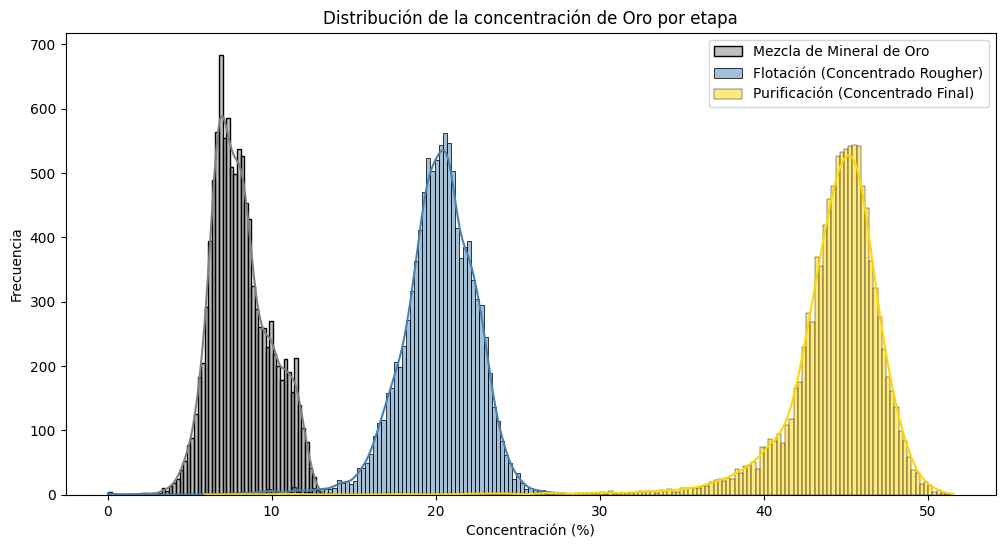

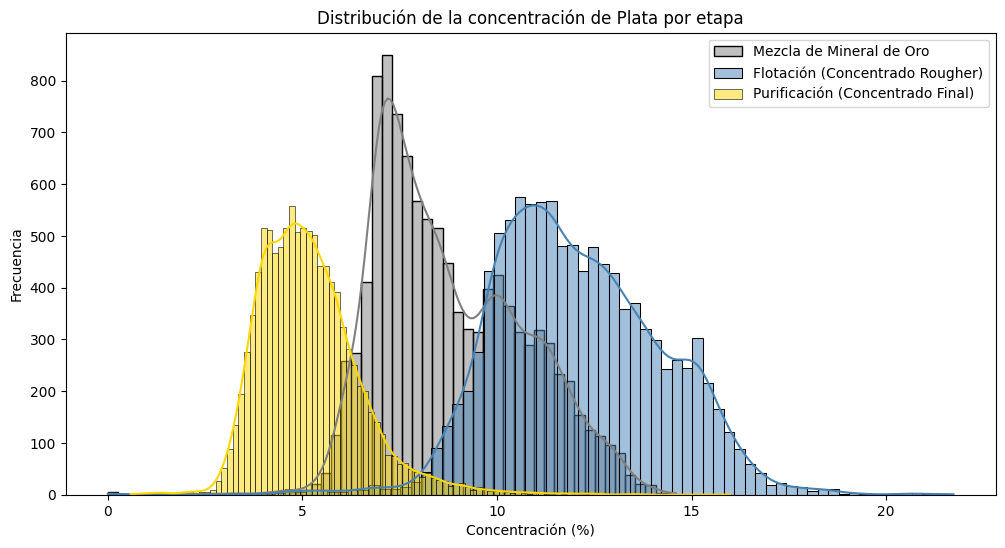

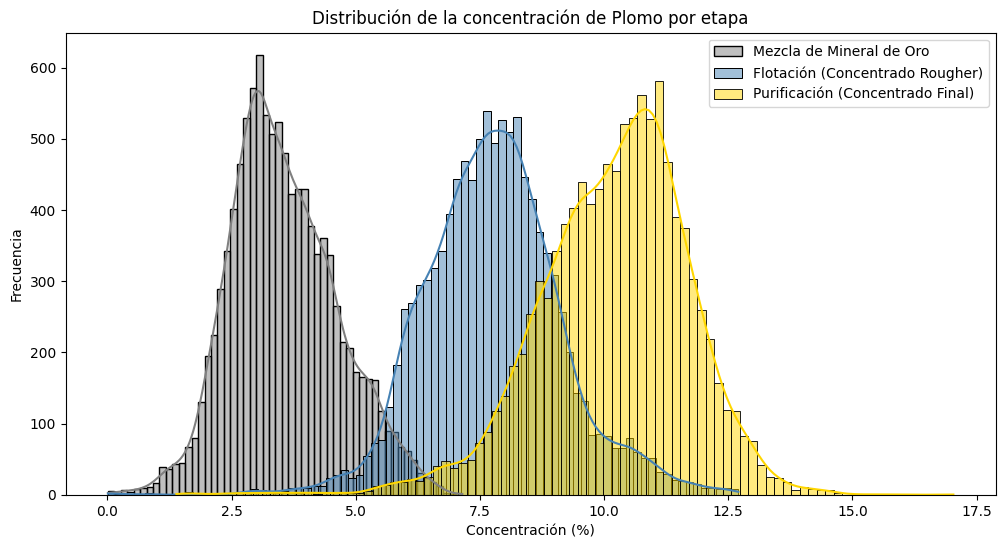

In [9]:
# Definiendo los metales y las etapas:
metales = {'au': 'Oro', 'ag': 'Plata', 'pb': 'Plomo'}

# Iterando sobre cada metal para graficar:
for metal, nombre in metales.items():
    plt.figure(figsize=(12, 6))
    sns.histplot(gold_recovery_train[f'rougher.input.feed_{metal}'], color="gray", label="Mezcla de Mineral de Oro", kde=True, alpha=0.5)
    sns.histplot(gold_recovery_train[f'rougher.output.concentrate_{metal}'], color="steelblue", label="Flotación (Concentrado Rougher)", kde=True, alpha=0.5)
    sns.histplot(gold_recovery_train[f'final.output.concentrate_{metal}'], color="gold", label="Purificación (Concentrado Final)", kde=True, alpha=0.5)

    # Generando los histogramas
    plt.title(f'Distribución de la concentración de {nombre} por etapa')
    plt.xlabel('Concentración (%)')
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.show()

### Conclusiones:

* En el Histograma: *Distribución de la concentración de Oro por etapa*, es fácil observar la eficiencia del proceso, se aprecia el incremento de la concentración de este mineral desde la alimentación (Mezcla de Mineral de Oro), hasta el producto final (Concentrado Final) después de la etapa de purificación.  La concentración aumenta de aproximadamente 8% a más del 45%.
  
* En el histograma: *Distribución de la concentración de Plata por etapa*, se puede apreciar cómo la cantidad de este elemento en el concentrado final disminuye considerablemente en la etapa de Purificación, reduciendo su concentración de aproximadamente 7.5% a 5% en el Concentrado Final.

* En el histograma: *Distribución de la concentración de Plomo por etapa*, se aprecia un comportamiento similar al del Oro, incrementando su concentración desde la alimentación inicial hasta el Concentrado Final, aumentando de aproximadamente 3% a 11%.

## 2.2 Comparación de la distribución del tamaño de las partículas de alimentación en el conjunto de entrenamiento y el conjunto de prueba:

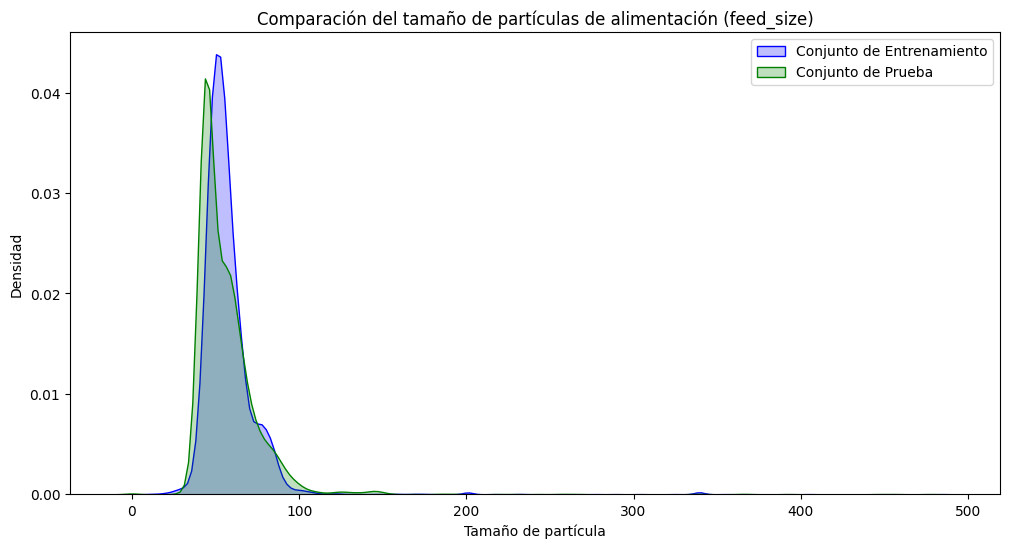

Tamaño promedio en el Conjunto de Entrenamiento: 57.32

Tamaño promedio en el Conjunto de Prueba: 56.37

  Las medias de ambos conjuntos son practicamente iguales.  



In [10]:
# Iniciando el grafico: 
plt.figure(figsize=(12, 6))

# Graficando las densidades para la comparación:
sns.kdeplot(gold_recovery_train['rougher.input.feed_size'], label='Conjunto de Entrenamiento', fill=True, color='blue')
sns.kdeplot(gold_recovery_test['rougher.input.feed_size'], label='Conjunto de Prueba', fill=True, color='green')
plt.title('Comparación del tamaño de partículas de alimentación (feed_size)')
plt.xlabel('Tamaño de partícula')
plt.ylabel('Densidad')
plt.legend()
plt.show()

# Mostrando las medias:
print(f"Tamaño promedio en el Conjunto de Entrenamiento: {round(gold_recovery_train['rougher.input.feed_size'].mean(),2)}")
print()
print(f"Tamaño promedio en el Conjunto de Prueba: {round(gold_recovery_test['rougher.input.feed_size'].mean(),2)}")
print()
print(f" \033[1m Las medias de ambos conjuntos son practicamente iguales. \033[0m ")
print()

### Conclusiones:

En el gráfico: *Comparación del tamaño de partículas de alimentación (feed_size)*, se puede apreciar que, aunque las modas (picos) presentan un ligero desplazamiento, las medias de ambos conjuntos son muy similares (57.32 vs 56.37). Dado que las distribuciones ocupan el mismo rango de valores y la diferencia entre promedios es inferior al 2%, se puede concluir que las variaciones en el tamaño de las partículas son aceptables y no representan un sesgo que pueda invalidar las predicciones del modelo.

## 2.3 Análisis de valores anormales por elemento en las diferentes etapas:

### Premisas:

Se analizará la **concentración total de sustancias (Au + Ag + Pb + sol)** como una medida de integridad física del proceso.

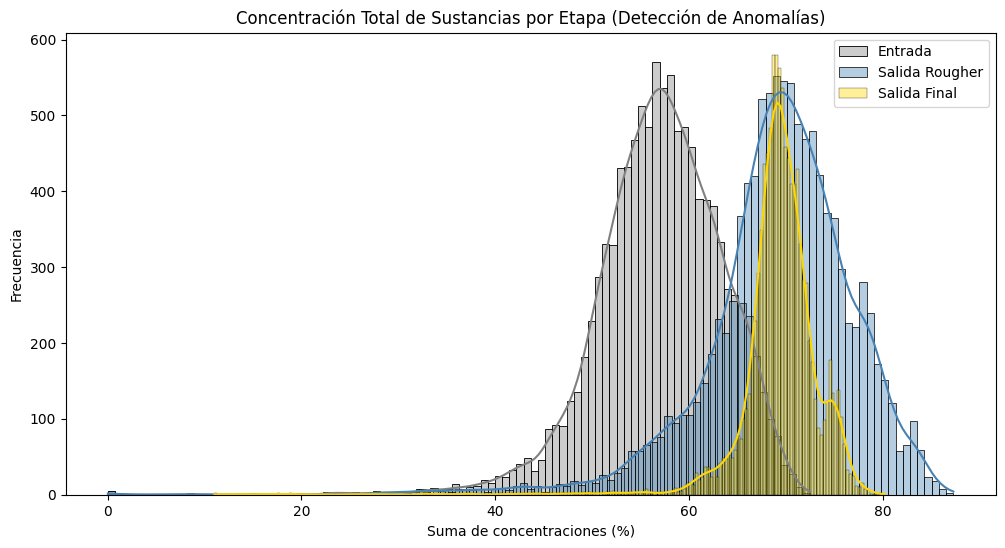

In [11]:
# Definiendo las columnas por etapa para sumar Au + Ag + Pb + sol:
entradas = ['rougher.input.feed_au', 'rougher.input.feed_ag', 'rougher.input.feed_pb', 'rougher.input.feed_sol']
concentracion_rougher = ['rougher.output.concentrate_au', 'rougher.output.concentrate_ag', 'rougher.output.concentrate_pb', 'rougher.output.concentrate_sol']
concentracion_final = ['final.output.concentrate_au', 'final.output.concentrate_ag', 'final.output.concentrate_pb', 'final.output.concentrate_sol']

# Creando las columnas de suma total:
gold_recovery_train['entradas'] = gold_recovery_train[entradas].sum(axis=1)
gold_recovery_train['concentracion_rougher'] = gold_recovery_train[concentracion_rougher].sum(axis=1)
gold_recovery_train['concentracion_final'] = gold_recovery_train[concentracion_final].sum(axis=1)

# Graficando para detectar los ceros:
plt.figure(figsize=(12, 6))
sns.histplot(gold_recovery_train['entradas'], color='gray', label='Entrada', kde=True, alpha=0.4)
sns.histplot(gold_recovery_train['concentracion_rougher'], color='steelblue', label='Salida Rougher', kde=True, alpha=0.4)
sns.histplot(gold_recovery_train['concentracion_final'], color='gold', label='Salida Final', kde=True, alpha=0.4)
plt.title('Concentración Total de Sustancias por Etapa (Detección de Anomalías)')
plt.xlabel('Suma de concentraciones (%)')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

### Observaciones:

En la distribución: *Concentración Total de Sustancias por Etapa (Detección de Anomalías)* se puede apreciar que los valores se encuentran entre 30% y 90% aproximadamente, sin embargo, existe una cantidad pequeña de valores en el cero.  Dado que es físicamente imposible tener una concentración total de cero durante la operación, los registros que se muestran en el extremo inferior de la distribución serán eliminados (los considerearé valores atípicos), ya que representan posibles fallos de los sensores o periodos de inactividad que sesgarían el entrenamiento del modelo.

In [12]:
# Eliminando filas donde la suma sea 0 o 5% como umbral:
len_original = len(gold_recovery_train)
gold_recovery_train = gold_recovery_train[(gold_recovery_train['entradas'] > 5) & (gold_recovery_train['concentracion_rougher'] > 5) & (gold_recovery_train['concentracion_final'] > 5)]
len_limpia = len(gold_recovery_train)

# Eliminando columnas innecesarias:
gold_recovery_train.drop(['entradas', 'concentracion_rougher', 'concentracion_final'], axis=1, inplace=True)

print(f" Con esta nuevo filtrado se eliminaron {len_original - len_limpia} filas.")

 Con esta nuevo filtrado se eliminaron 6 filas.


### Conclusiones:

Luego de eliminar las filas donde la concentración total se mantiene dentro de un umbral de filtrado del 5%,  sólo se identificaron 6 registros anómalos (menos del 0.05% del dataset), lo que confirma la alta calidad y coherencia de las mediciones recolectadas para el entrenamiento del modelo.

<div class="alert alert-block alert-success">  
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>  
<b>Éxito</b> - La sección de análisis es sólida, estructurada y revela un alto nivel de criterio técnico. Tus gráficos son pertinentes y tus interpretaciones están bien fundamentadas en el contexto del proceso minero. Es destacable el uso de la concentración total de sustancias como indicador de integridad del proceso y la aplicación de un umbral razonable del 5% para filtrar anomalías. Además, justificaste adecuadamente la similitud de distribuciones entre los datasets de entrenamiento y prueba, lo que valida el uso del modelo sin riesgo de sesgo. Muy buen trabajo.
</div>


# 3. Construyendo el Modelo:

## 3.1 Función para el cálculo del valor final de sMAPE:

In [13]:
# Función para el cálculo de sMAPE:
def calculo_smape(target, prediction):
    smape = np.mean(np.abs(target - prediction) / ((np.abs(target) + np.abs(prediction)) / 2)) * 100
    return smape

# Función para el cálculo del Valor Final de sMAPE:
def calculo_final_smape(target_rougher, pred_rougher, target_final, pred_final):
    smape_rougher = calculo_smape(target_rougher, pred_rougher)
    smape_final = calculo_smape(target_final, pred_final)
    valor_final_smape = 0.25 * smape_rougher + 0.75 * smape_final
    return valor_final_smape

## 3.2 Entrenando diferentes modelos y evaluando con validación cruzada:

### 3.2.1 Preparando los conjuntos de datos para features y target:

In [14]:
# Por la diferencia entre las columnas de train y test, se deben preparar los conjuntos antes del entrenamiento 
# para que tengan las mismas columnas:

# Utilizare el Conjunto full para completar la información faltante en el conjunto test:
gold_recovery_test = gold_recovery_test.merge(gold_recovery_full[['date', 'rougher.output.recovery', 'final.output.recovery']],on='date',how='left')

# Eliminando cualquier nulo que haya aparecido tras la unión:
gold_recovery_test.dropna(inplace=True)

# Identificando las columnas a utilizar como features:
features_list = [col for col in gold_recovery_test.columns if col not in ['date', 'rougher.output.recovery', 'final.output.recovery']]

# Preparando los datos de Entrenamiento:
features_train = gold_recovery_train[features_list]
target_train_rougher = gold_recovery_train['rougher.output.recovery']
target_train_final = gold_recovery_train['final.output.recovery']

# Preparando los datos de Prueba:
features_test = gold_recovery_test[features_list]
target_test_rougher = gold_recovery_test['rougher.output.recovery']
target_test_final = gold_recovery_test['final.output.recovery']

### 3.2.2 Entrenando y evaluando el 1er modelo: Regresión Lineal:

In [15]:
# Creando el scorer para usarlo en la validación cruzada:
smape_scorer = make_scorer(calculo_smape, greater_is_better=False)

# Creando el Modelo:
model_1 = LinearRegression()

# Validación cruzada para la etapa Rougher
scores_rougher = cross_val_score(model_1, features_train, target_train_rougher, cv=5, scoring=smape_scorer)
# Validación cruzada para la etapa Final
scores_final = cross_val_score(model_1, features_train, target_train_final, cv=5, scoring=smape_scorer)

# Calculamos el promedio de los 5 resultados:
avg_smape_rougher = abs(scores_rougher.mean())
avg_smape_final = abs(scores_final.mean())

# Cálculo final ponderado (25% Rougher + 75% Final)
final_smape_1 = 0.25 * avg_smape_rougher + 0.75 * avg_smape_final

print(f"\033[1mError Medio Absoluto Porcentual Simetrico para el Modelo de Regresión Lineal:\033[0m")
print()
print(f"sMAPE Promedio Etapa #1 (Rougher): {round(avg_smape_rougher,2)}%")
print()
print(f"sMAPE Promedio Final: {round(avg_smape_final,2)}%")
print()
print(f"\033[1msMAPE FINAL (Regresión Lineal): {round(final_smape_1,2)}% \033[0m")
print()

Error Medio Absoluto Porcentual Simetrico para el Modelo de Regresión Lineal:

sMAPE Promedio Etapa #1 (Rougher): 6.16%

sMAPE Promedio Final: 9.08%

sMAPE FINAL (Regresión Lineal): 8.35% 



### 3.2.3 Entrenando y evaluando el 2do modelo: Arbol de Decisión:

In [16]:
# Probaremos diferentes profundidades para ver cuál es la mejor
best_model_dt = None
best_final_smape = 10
best_depth = 0

for depth in range(1, 11):
    model_2 = DecisionTreeRegressor(max_depth=depth, random_state=13099213)
    
    # Validación cruzada para la etapa Rougher
    scores_rougher = cross_val_score(model_2, features_train, target_train_rougher, cv=5, scoring=smape_scorer)
    # Validación cruzada para la etapa Final
    scores_final = cross_val_score(model_2, features_train, target_train_final, cv=5, scoring=smape_scorer)
    
    # Calculamos el promedio de los 5 resultados:
    avg_smape_rougher = abs(scores_rougher.mean())
    avg_smape_final = abs(scores_final.mean())

    # Cálculo final ponderado (25% Rougher + 75% Final)
    final_smape_calculado = 0.25 * avg_smape_rougher + 0.75 * avg_smape_final

    print(f"Profundidad {depth}: sMAPE Final = {final_smape_calculado:.2f}%")
    
    if final_smape_calculado < best_final_smape:
        best_final_smape = final_smape_calculado
        best_depth = depth
        best_model_dt = model_2
        best_avg_smape_rougher = avg_smape_rougher
        best_avg_smape_final = avg_smape_final
print()
print(f"\033[1mError Medio Absoluto Porcentual Simetrico para el Modelo de Arbol de Decisión:\033[0m")
print()
print(f"Mejor Profundidad: {best_depth}")
print()
print(f"sMAPE Promedio Etapa #1 (Rougher): {round(best_avg_smape_rougher,2)}%")
print()
print(f"sMAPE Promedio Final: {round(best_avg_smape_final,2)}%")
print()
print(f"\033[1msMAPE FINAL (Arbol Aleatorio): {round(best_final_smape,2)}% \033[0m")
print()

Profundidad 1: sMAPE Final = 7.95%
Profundidad 2: sMAPE Final = 8.81%
Profundidad 3: sMAPE Final = 9.51%
Profundidad 4: sMAPE Final = 8.75%
Profundidad 5: sMAPE Final = 8.46%
Profundidad 6: sMAPE Final = 8.78%
Profundidad 7: sMAPE Final = 9.43%
Profundidad 8: sMAPE Final = 9.87%
Profundidad 9: sMAPE Final = 11.22%
Profundidad 10: sMAPE Final = 12.03%

Error Medio Absoluto Porcentual Simetrico para el Modelo de Arbol de Decisión:

Mejor Profundidad: 1

sMAPE Promedio Etapa #1 (Rougher): 7.15%

sMAPE Promedio Final: 8.22%

sMAPE FINAL (Arbol Aleatorio): 7.95% 



### 3.2.3 Entrenando y evaluando el 3er modelo: Bosque Aleatorio:

In [17]:
# Inicializando la variable final_smape_3 para el lazo:
final_smape_3 = 10

# Creando el lazo para evaluar el modelo variando la profundidad:
for depth in range(1, 11):
    model_3 = RandomForestRegressor(n_estimators=60, max_depth=depth, random_state=13099213)

    # Validación cruzada para la etapa Rougher
    scores_rougher = cross_val_score(model_3, features_train, target_train_rougher, cv=5, scoring=smape_scorer)
    # Validación cruzada para la etapa Final
    scores_final = cross_val_score(model_3, features_train, target_train_final, cv=5, scoring=smape_scorer)

    # Calculamos el promedio de los 5 resultados:
    avg_smape_rougher = abs(scores_rougher.mean())
    avg_smape_final = abs(scores_final.mean())

    # Cálculo final ponderado (25% Rougher + 75% Final)
    final_smape_calculado = 0.25 * avg_smape_rougher + 0.75 * avg_smape_final

    print(f"Profundidad {depth}: sMAPE Final = {round(final_smape_calculado,2)}%")

    # Guardando los mejores valores:
    if final_smape_3 > final_smape_calculado:
        final_smape_3 = final_smape_calculado
        depth_final = depth
        avg_smape_rougher_final = avg_smape_rougher
        avg_smape_final_final = avg_smape_final
print()
print(f"\033[1mError Medio Absoluto Porcentual Simetrico para el Modelo de Bosque Aleatorio:\033[0m")
print()
print(f"sMAPE Promedio Etapa #1 (Rougher): {round(avg_smape_rougher_final,2)}%")
print()
print(f"sMAPE Promedio Final: {round(avg_smape_final_final,2)}%")
print()
print(f"\033[1msMAPE FINAL (Bosque Aleatorio): {round(final_smape_3,2)}% \033[0m")
print()

Profundidad 1: sMAPE Final = 7.9%
Profundidad 2: sMAPE Final = 8.43%
Profundidad 3: sMAPE Final = 8.58%
Profundidad 4: sMAPE Final = 8.44%
Profundidad 5: sMAPE Final = 8.17%
Profundidad 6: sMAPE Final = 8.27%
Profundidad 7: sMAPE Final = 8.38%
Profundidad 8: sMAPE Final = 8.56%
Profundidad 9: sMAPE Final = 8.56%
Profundidad 10: sMAPE Final = 8.6%

Error Medio Absoluto Porcentual Simetrico para el Modelo de Bosque Aleatorio:

sMAPE Promedio Etapa #1 (Rougher): 7.13%

sMAPE Promedio Final: 8.16%

sMAPE FINAL (Bosque Aleatorio): 7.9% 



In [18]:
# Tabulando los resultados:

resultados = {'Modelo': ['Regresión Lineal', 'Arbol de Decisión', 'Bosque Aleatorio'], 
              'sMAPE': ['8.35%', '7.95%', '7.90%']}
resultados = pd.DataFrame(resultados)
print()
print(f"Los resultados para la selección del modelo se muestran en la tabla:")
print()
display(resultados)


Los resultados para la selección del modelo se muestran en la tabla:



,Modelo,sMAPE
0,Regresión Lineal,8.35%
1,Arbol de Decisión,7.95%
2,Bosque Aleatorio,7.90%


### Conclusiones:

Tomando como premisa de selección del modelo el menor sMAPE, siguiendo los resultados de la tabla anterior, el mejor de los tres modelos evaluados para el proceso de la mina es de **Bosque Aleatorio, con 50 estimadores y profundidad de 1**. Este modelo resulta en el menor sMAPE, con un valor de **7,90%**.


### 3.2.4 Prueba del Modelo seleccionado con el Conjunto de Prueba:

In [19]:
# Entrenar el modelo ganador:
model_rougher = RandomForestRegressor(n_estimators=50, max_depth=1, random_state=13099213)
model_final = RandomForestRegressor(n_estimators=50, max_depth=1, random_state=13099213)
model_rougher.fit(features_train, target_train_rougher)
model_final.fit(features_train, target_train_final)

# Prediciendo con el conjunto de prueba:
test_predictions_rougher = model_rougher.predict(features_test)
test_predictions_final = model_final.predict(features_test)

# Calculando el sMAPE Final del modelo:
final_smape_test = calculo_final_smape(target_test_rougher, test_predictions_rougher, target_test_final, test_predictions_final)
print()
print(f"\033[1mError Medio Absoluto Porcentual Simetrico para el Modelo de Bosque Aleatorio ganador:\033[0m")
print()
print(f"\033[1msMAPE FINAL: {round(final_smape_test,2)}% \033[0m")
print()


Error Medio Absoluto Porcentual Simetrico para el Modelo de Bosque Aleatorio ganador:

sMAPE FINAL: 6.84% 



### 3.2.5 Prueba de Cordura del Modelo seleccionado:

In [20]:
# Entrenando un modelo que solo predice el promedio:
dummy_rougher = DummyRegressor(strategy='mean').fit(features_train, target_train_rougher)
dummy_final = DummyRegressor(strategy='mean').fit(features_train, target_train_final)

# Predicciones promedio:
d_pred_rougher = dummy_rougher.predict(features_test)
d_pred_final = dummy_final.predict(features_test)

# Calculando el sMAPE Final del modelo:
final_smape_dummy = calculo_final_smape(target_test_rougher, d_pred_rougher, target_test_final, d_pred_final)
print()
print(f"\033[1mError Medio Absoluto Porcentual Simetrico para el Modelo Dummy:\033[0m")
print()
print(f"\033[1msMAPE FINAL: {round(final_smape_dummy,2)}% \033[0m")
print()


Error Medio Absoluto Porcentual Simetrico para el Modelo Dummy:

sMAPE FINAL: 7.39% 



In [21]:
# Tabulando los resultados:

resultados_final = {'Modelo': ['Bosque Aleatorio (Test)', 'Dummy'],'sMAPE': ['6.84%', '7.39%']}
resultados_final = pd.DataFrame(resultados_final)
print()
print(f"Los resultados para el sMAPE en el conjunto de prueba y de la prueba de Cordura, se muestran en la tabla:")
print()
display(resultados_final)



Los resultados para el sMAPE en el conjunto de prueba y de la prueba de Cordura, se muestran en la tabla:



,Modelo,sMAPE
0,Bosque Aleatorio (Test),6.84%
1,Dummy,7.39%


### Conclusiones:

Al aplicar el modelo seleccionado al **conjunto de prueba final (Test)**, se obtuvo un **sMAPE de 6.84%**, superando el desempeño del **modelo constante (Dummy)** que obtuvo un **7.39%**. 

***Esto demuestra que el modelo tiene capacidad predictiva real y es altamente robusto, siendo ideal para su implementación en sistemas con recursos computacionales limitados sin sacrificar precisión.***

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br> 
    
<b>Éxito</b> – Tu trabajo se presenta como un recorrido bien estructurado, desde una comprensión inicial del problema hasta la validación del modelo final. La claridad con la que describes cada decisión técnica y el razonamiento detrás de las elecciones metodológicas le otorgan a tu proyecto un tono profesional y confiable. Has logrado una síntesis muy efectiva entre limpieza de datos, análisis exploratorio y evaluación de modelos. El contraste con el modelo dummy fue una excelente forma de justificar la validez del modelo elegido. El cierre que redactaste refuerza los hallazgos de forma concisa y pertinente.  
</div>


# Comentario General del Revisor

<div class="alert alert-block alert-success">  
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>  

    
¡Felicidades! Tu proyecto está **aprobado**. Presentas un trabajo sólido, coherente y bien estructurado, que evidencia una comprensión clara tanto del problema como del contexto industrial. A lo largo del notebook mantuviste un hilo lógico, con decisiones técnicas bien justificadas y correctamente alineadas con el brief del proyecto.  

#### Puntos positivos:

* **Preparación y limpieza de datos:** Aplicaste criterios realistas y consistentes para el tratamiento de valores nulos y anomalías, priorizando la integridad de la información y evitando introducir sesgos artificiales.
* **Validación del cálculo de recuperación:** Comprobaste correctamente la fórmula de recuperación, demostrando atención al detalle y verificación de la calidad de los datos.
* **Análisis exploratorio:** Interpretaste de forma clara los cambios en la concentración de metales y justificaste adecuadamente la comparabilidad entre los conjuntos de entrenamiento y prueba.
* **Modelado y evaluación:** Definiste correctamente la métrica sMAPE, utilizaste validación cruzada y comparaste distintos modelos de manera ordenada y transparente.
* **Evaluación crítica:** La prueba de cordura con el modelo dummy refuerza la credibilidad del modelo final y demuestra criterio analítico.

En conjunto, entregas un pipeline bien construido, robusto y listo para un escenario real de implementación, cumpliendo con todos los requisitos del proyecto y mostrando un excelente manejo del proceso completo de análisis y modelado.

</div>
